### Практическая работа №7: Бустинг

Выполнил: Чашин Денис, ЕТ-128

In [6]:
# Библиотеки
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [7]:
iris = datasets.load_iris()

X = iris.data
y = iris.target

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.8,
    random_state=42,
    stratify=y
)

In [9]:
estimators_range = list(range(50, 110, 10))

acc_list = []
prec_list = []
rec_list = []
f1_list = []

In [10]:
# Обучение

for n in estimators_range:

    model = AdaBoostClassifier(
        n_estimators=n,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc_list.append(accuracy_score(y_test, y_pred))
    prec_list.append(precision_score(y_test, y_pred, average='macro'))
    rec_list.append(recall_score(y_test, y_pred, average='macro'))
    f1_list.append(f1_score(y_test, y_pred, average='macro'))

In [11]:
df_results = pd.DataFrame({
    "Количество моделей": estimators_range,
    "Accuracy": acc_list,
    "Precision": prec_list,
    "Recall": rec_list,
    "F1": f1_list
})

df_results

,Количество моделей,Accuracy,Precision,Recall,F1
0,50,0.933333,0.933333,0.933333,0.933333
1,60,0.933333,0.933333,0.933333,0.933333
2,70,0.933333,0.933333,0.933333,0.933333
3,80,0.933333,0.933333,0.933333,0.933333
4,90,0.933333,0.933333,0.933333,0.933333
5,100,0.933333,0.933333,0.933333,0.933333


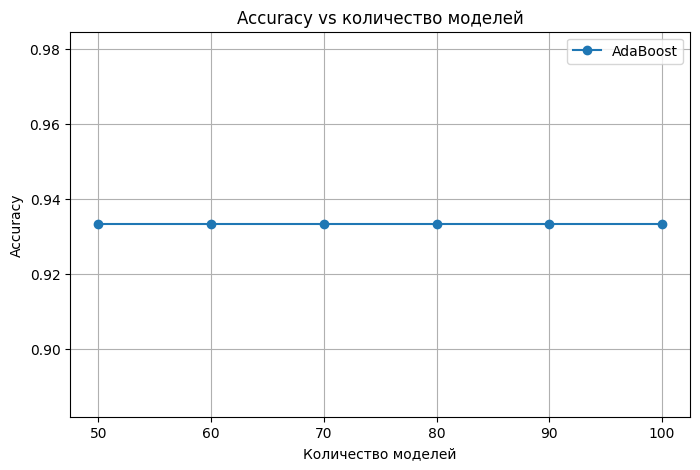

In [12]:
plt.figure(figsize=(8,5))

plt.plot(estimators_range, acc_list, marker='o', label="AdaBoost")

plt.title("Accuracy vs количество моделей")
plt.xlabel("Количество моделей")
plt.ylabel("Accuracy")

plt.grid(True)
plt.legend()
plt.show()

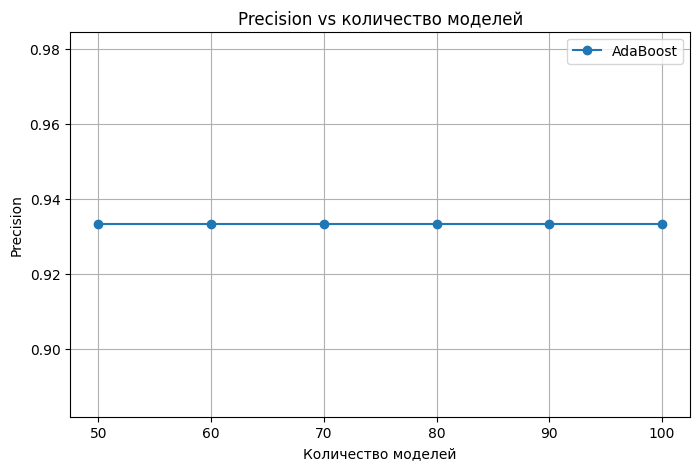

In [13]:
plt.figure(figsize=(8,5))

plt.plot(estimators_range, prec_list, marker='o', label="AdaBoost")

plt.title("Precision vs количество моделей")
plt.xlabel("Количество моделей")
plt.ylabel("Precision")

plt.grid(True)
plt.legend()
plt.show()

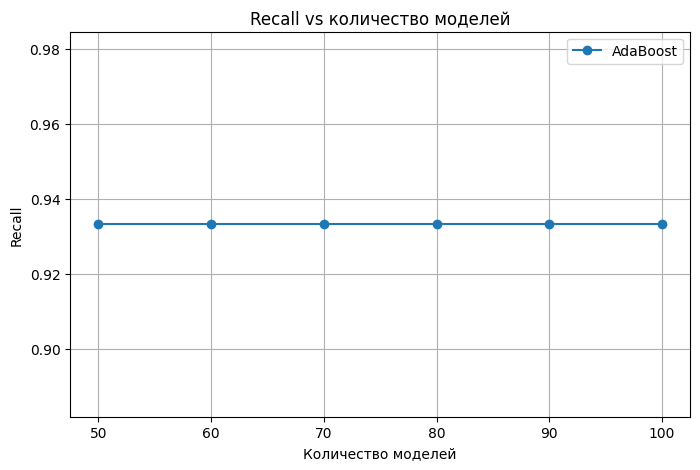

In [14]:
plt.figure(figsize=(8,5))

plt.plot(estimators_range, rec_list, marker='o', label="AdaBoost")

plt.title("Recall vs количество моделей")
plt.xlabel("Количество моделей")
plt.ylabel("Recall")

plt.grid(True)
plt.legend()
plt.show()

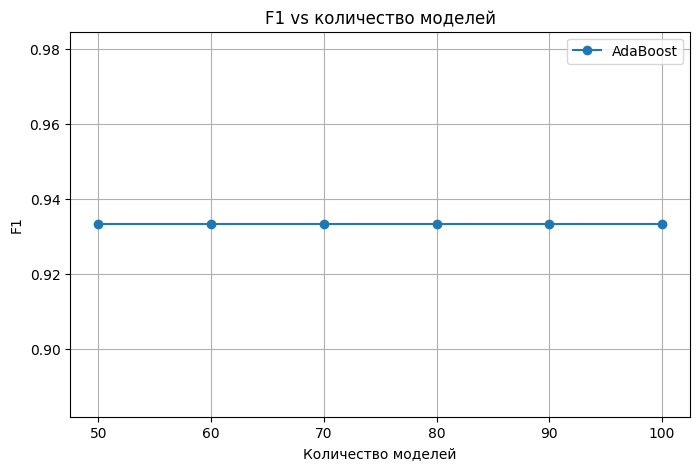

In [15]:
plt.figure(figsize=(8,5))

plt.plot(estimators_range, f1_list, marker='o', label="AdaBoost")

plt.title("F1 vs количество моделей")
plt.xlabel("Количество моделей")
plt.ylabel("F1")

plt.grid(True)
plt.legend()
plt.show()

In [16]:
# Размеры обучающей выборки
train_sizes = list(range(60, 95, 5))
train_sizes

[60, 65, 70, 75, 80, 85, 90]

In [17]:
def calc_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="macro"),
        "recall": recall_score(y_true, y_pred, average="macro"),
        "f1": f1_score(y_true, y_pred, average="macro")
    }

In [18]:
# 1. Байесовская классификация
nb_rows = []

for tr in train_sizes:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        train_size=tr / 100,
        random_state=42,
        stratify=y
    )

    model = GaussianNB()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    metrics = calc_metrics(y_test, y_pred)
    nb_rows.append({
        "train_size": tr,
        "model": "GaussianNB",
        "variant": "default",
        **metrics
    })

nb_results = pd.DataFrame(nb_rows)
nb_results

,train_size,model,variant,accuracy,precision,recall,f1
0,60,GaussianNB,default,0.933333,0.936027,0.933333,0.933166
1,65,GaussianNB,default,0.924528,0.929167,0.925926,0.925697
2,70,GaussianNB,default,0.911111,0.915535,0.911111,0.910714
3,75,GaussianNB,default,0.921053,0.924603,0.923077,0.922963
4,80,GaussianNB,default,0.966667,0.969697,0.966667,0.966583
5,85,GaussianNB,default,0.913043,0.916667,0.916667,0.916667
6,90,GaussianNB,default,0.866667,0.866667,0.866667,0.866667


In [19]:
# 2. Деревья решений
tree_rows = []

for criterion in ["gini"]:
    for tr in train_sizes:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            train_size=tr / 100,
            random_state=42,
            stratify=y
        )

        model = DecisionTreeClassifier(
            criterion=criterion,
            random_state=42
        )
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        metrics = calc_metrics(y_test, y_pred)
        tree_rows.append({
            "train_size": tr,
            "model": "DecisionTree",
            "variant": criterion,
            **metrics
        })

tree_results = pd.DataFrame(tree_rows)
tree_results

,train_size,model,variant,accuracy,precision,recall,f1
0,60,DecisionTree,gini,0.950000,0.950710,0.950000,0.949969
1,65,DecisionTree,gini,0.943396,0.945304,0.944444,0.944402
2,70,DecisionTree,gini,0.933333,0.944444,0.933333,0.932660
3,75,DecisionTree,gini,0.894737,0.903030,0.897436,0.896825
4,80,DecisionTree,gini,0.933333,0.933333,0.933333,0.933333
5,85,DecisionTree,gini,0.913043,0.916667,0.916667,0.916667
6,90,DecisionTree,gini,0.866667,0.866667,0.866667,0.866667


In [20]:
# 3. Бэггинг
bagging_rows = []

for tr in train_sizes:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        train_size=tr / 100,
        random_state=42,
        stratify=y
    )

    model = BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=50,
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    metrics = calc_metrics(y_test, y_pred)
    bagging_rows.append({
        "train_size": tr,
        "model": "Bagging",
        "variant": f"n_estimators={50}",
        **metrics
    })

bagging_results = pd.DataFrame(bagging_rows)
bagging_results

,train_size,model,variant,accuracy,precision,recall,f1
0,60,Bagging,n_estimators=50,0.966667,0.966667,0.966667,0.966667
1,65,Bagging,n_estimators=50,0.924528,0.929167,0.925926,0.925697
2,70,Bagging,n_estimators=50,0.933333,0.934524,0.933333,0.933259
3,75,Bagging,n_estimators=50,0.921053,0.924603,0.923077,0.922963
4,80,Bagging,n_estimators=50,0.966667,0.969697,0.966667,0.966583
5,85,Bagging,n_estimators=50,0.956522,0.962963,0.958333,0.958170
6,90,Bagging,n_estimators=50,0.933333,0.944444,0.933333,0.932660


In [21]:
# 4. Случайный лес
rf_rows = []

for tr in train_sizes:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        train_size=tr / 100,
        random_state=42,
        stratify=y
    )

    model = RandomForestClassifier(
        n_estimators=80,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    metrics = calc_metrics(y_test, y_pred)

    rf_rows.append({
        "train_size": tr,
        **metrics
    })

rf_results = pd.DataFrame(rf_rows)
rf_results

,train_size,accuracy,precision,recall,f1
0,60,0.916667,0.922421,0.916667,0.916195
1,65,0.905660,0.914286,0.907407,0.906760
2,70,0.888889,0.898148,0.888889,0.887767
3,75,0.921053,0.924603,0.923077,0.922963
4,80,0.933333,0.933333,0.933333,0.933333
5,85,0.913043,0.916667,0.916667,0.916667
6,90,0.933333,0.944444,0.933333,0.932660


In [22]:
# 5. Бустинг
boost_rows = []

for tr in train_sizes:

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        train_size=tr / 100,
        random_state=42,
        stratify=y
    )

    model = AdaBoostClassifier(
        n_estimators=50,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    m = calc_metrics(y_test, y_pred)

    boost_rows.append({
        "train_size": tr,
        "accuracy": m["accuracy"],
        "precision": m["precision"],
        "recall": m["recall"],
        "f1": m["f1"]
    })

boost_results = pd.DataFrame(boost_rows)

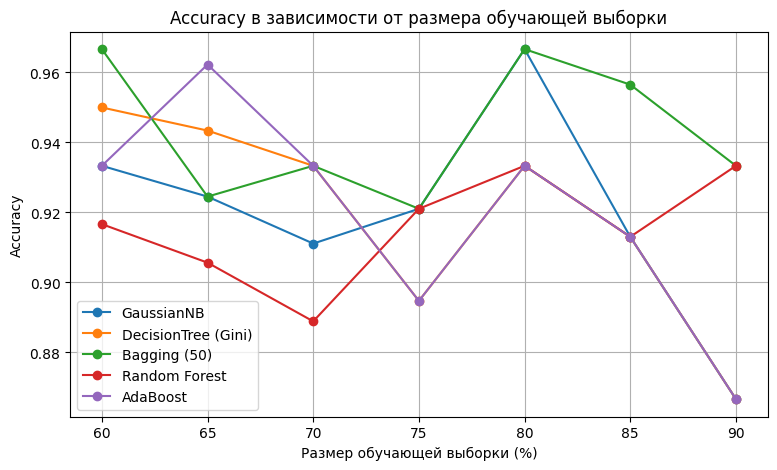

In [23]:
plt.figure(figsize=(9, 5))
plt.plot(nb_results["train_size"], nb_results["accuracy"], marker="o", label="GaussianNB")
plt.plot(tree_results["train_size"], tree_results["accuracy"], marker="o", label=f"DecisionTree (Gini)")
plt.plot(bagging_results["train_size"], bagging_results["accuracy"], marker="o", label=f"Bagging (50)")
plt.plot(rf_results["train_size"], rf_results["accuracy"], marker="o", label="Random Forest")
plt.plot(boost_results["train_size"], boost_results["accuracy"], marker="o", label="AdaBoost")

plt.title("Accuracy в зависимости от размера обучающей выборки")
plt.xlabel("Размер обучающей выборки (%)")
plt.ylabel("Accuracy")
plt.xticks(train_sizes)
plt.grid(True)
plt.legend()
plt.show()

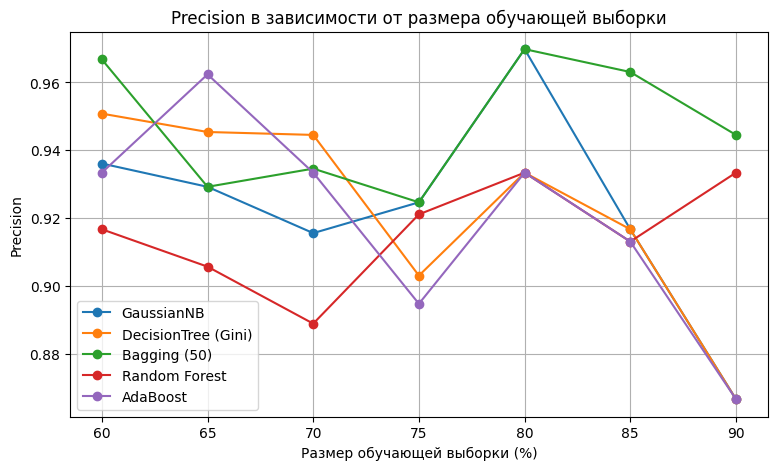

In [24]:
plt.figure(figsize=(9, 5))
plt.plot(nb_results["train_size"], nb_results["precision"], marker="o", label="GaussianNB")
plt.plot(tree_results["train_size"], tree_results["precision"], marker="o", label=f"DecisionTree (Gini)")
plt.plot(bagging_results["train_size"], bagging_results["precision"], marker="o", label=f"Bagging (50)")
plt.plot(rf_results["train_size"], rf_results["accuracy"], marker="o", label="Random Forest")
plt.plot(boost_results["train_size"], boost_results["accuracy"], marker="o", label="AdaBoost")

plt.title("Precision в зависимости от размера обучающей выборки")
plt.xlabel("Размер обучающей выборки (%)")
plt.ylabel("Precision")
plt.xticks(train_sizes)
plt.grid(True)
plt.legend()
plt.show()

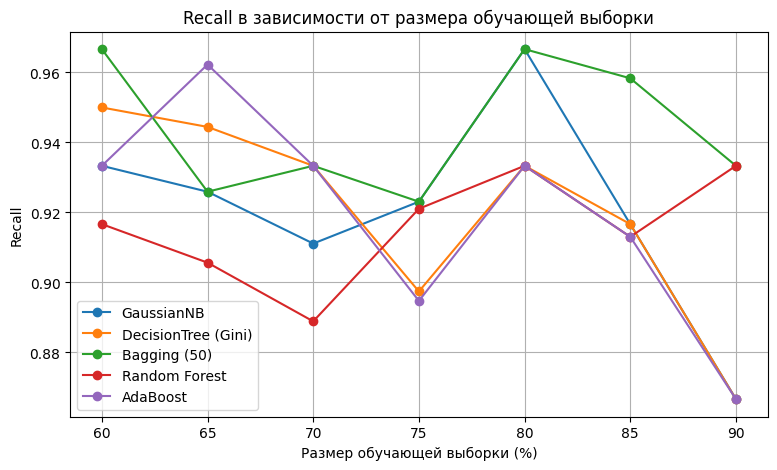

In [25]:
plt.figure(figsize=(9, 5))
plt.plot(nb_results["train_size"], nb_results["recall"], marker="o", label="GaussianNB")
plt.plot(tree_results["train_size"], tree_results["recall"], marker="o", label=f"DecisionTree (Gini)")
plt.plot(bagging_results["train_size"], bagging_results["recall"], marker="o", label=f"Bagging (50)")
plt.plot(rf_results["train_size"], rf_results["accuracy"], marker="o", label="Random Forest")
plt.plot(boost_results["train_size"], boost_results["accuracy"], marker="o", label="AdaBoost")

plt.title("Recall в зависимости от размера обучающей выборки")
plt.xlabel("Размер обучающей выборки (%)")
plt.ylabel("Recall")
plt.xticks(train_sizes)
plt.grid(True)
plt.legend()
plt.show()

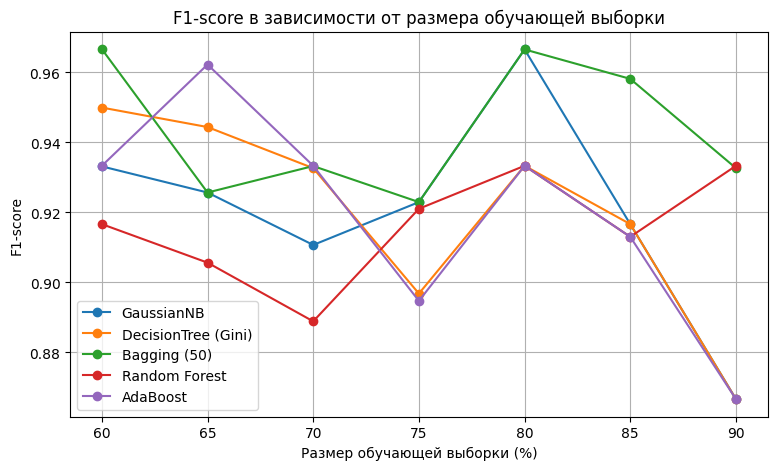

In [26]:
plt.figure(figsize=(9, 5))
plt.plot(nb_results["train_size"], nb_results["f1"], marker="o", label="GaussianNB")
plt.plot(tree_results["train_size"], tree_results["f1"], marker="o", label=f"DecisionTree (Gini)")
plt.plot(bagging_results["train_size"], bagging_results["f1"], marker="o", label=f"Bagging (50)")
plt.plot(rf_results["train_size"], rf_results["accuracy"], marker="o", label="Random Forest")
plt.plot(boost_results["train_size"], boost_results["accuracy"], marker="o", label="AdaBoost")

plt.title("F1-score в зависимости от размера обучающей выборки")
plt.xlabel("Размер обучающей выборки (%)")
plt.ylabel("F1-score")
plt.xticks(train_sizes)
plt.grid(True)
plt.legend()
plt.show()